In [1]:
from datetime import datetime
import pandas as pd
import numpy as np

from sklearn.model_selection import ParameterGrid
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score

from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_SEED = 694973
np.random.seed(RANDOM_SEED)

# for reproducibility
print("pandas: "+pd.__version__)
print("numpy: "+np.__version__)
import sklearn
print("sklearn: "+sklearn.__version__)

pandas: 3.0.1
numpy: 2.4.3
sklearn: 1.8.0


In [2]:
df = pd.read_csv('data/shot_probs_data.csv')
df.head()

,distance,angle,shot_type_numeric,shot_type,is_behind_backboard,set_name,is_made
0,0.187613,0.195018,0,JUMPER,0,train,0
1,0.029004,0.524437,1,LAYUP,0,train,0
2,0.115727,0.422763,0,JUMPER,0,train,1
3,0.256781,0.472390,0,JUMPER,0,train,1
4,0.109662,0.224862,0,JUMPER,0,train,1


In [3]:
def make_dataset(df:pd.DataFrame, set_name:str):
    dff = df.loc[df['set_name']==set_name].drop(['set_name','is_made','shot_type','shot_type_numeric'],axis=1).reset_index(drop=True)
    target = df.loc[df['set_name']==set_name]['is_made'].values
    shot_name_vals = df.loc[df['set_name']==set_name]['shot_type'].values
    return dff, target, shot_name_vals

X_train_mm, y_train, shot_train = make_dataset(df, 'train')
X_val_mm, y_val, shot_val = make_dataset(df, 'val')
X_query_mm, y_query, shot_query = make_dataset(df, 'query')
X_test_mm, y_test, shot_test = make_dataset(df, 'test')

print(X_train_mm.shape, X_val_mm.shape, X_query_mm.shape, X_test_mm.shape)

(1612163, 3) (690928, 3) (493520, 3) (493519, 3)


In [4]:
X_train_mm.head()

,distance,angle,is_behind_backboard
0,0.187613,0.195018,0
1,0.029004,0.524437,0
2,0.115727,0.422763,0
3,0.256781,0.472390,0
4,0.109662,0.224862,0


In [5]:
def compute_scores(target, preds):
    loss = log_loss(target, preds)
    auc = roc_auc_score(target, preds)
    binary_preds = (preds >= 0.5).astype(int)
    accuracy = accuracy_score(target, binary_preds)
    return loss, auc, accuracy

def score_model(model, X, y, model_name=None):
    if model_name == 'nn':
        preds = model.predict_proba(X)
    else:
        preds = model.predict_proba(X)[:,1]
    loss, auc, acc = compute_scores(y, preds)
    print(f"Log Loss: {loss:.4f}, AUC: {auc:.4f}, Accuracy: {acc:.4f}")
    return None

In [6]:
# logistic regression
log_params = {
    'C': [1e-2, 1, 1e1, 1e2, 1e3, 1e4, 1e5, 1e10, 1e20, 1e100, np.inf],
    'solver':['lbfgs','newton-cholesky',]
}
log_grid = ParameterGrid(log_params)
best_score = float('inf')
best_params = None
best_iteration = 0
start = datetime.now()
for i, params in enumerate(log_grid):
    model = LogisticRegression(
        **params,
        max_iter=10000,
        random_state=RANDOM_SEED
    )
    model.fit(
        X_train_mm, y_train,
    )
    y_val_preds = model.predict_proba(X_val_mm)
    current_score = log_loss(y_val, y_val_preds)
    if current_score < best_score:
        best_score = current_score
        best_model = model
        best_params = params
end = datetime.now()

print('fit time: '+str(round((end - start).total_seconds()/60,2)))
print(best_params)
print(best_score)

fit time: 0.14
{'C': 1, 'solver': 'lbfgs'}
0.6668593814405709


In [7]:
def plot_cali_curve(truth, probs, label, color, nbins=30):
    prob_true, prob_pred = calibration_curve(truth, probs, n_bins=nbins)
    bindf = pd.DataFrame({'truth':truth, 'prob': probs})
    bin_edge = np.linspace(0, 1, nbins + 1)
    bindf['bin'] = pd.cut(bindf['prob'], bins=bin_edge)
    bin_counts = bindf.groupby('bin', observed=True).size().values
    plt.plot(prob_pred, prob_true, color=color, label=label)
    dot_sze = (bin_counts / bin_counts.max())*100
    plt.scatter(prob_pred, prob_true, color=color, s=dot_sze, label="_nolegend_")

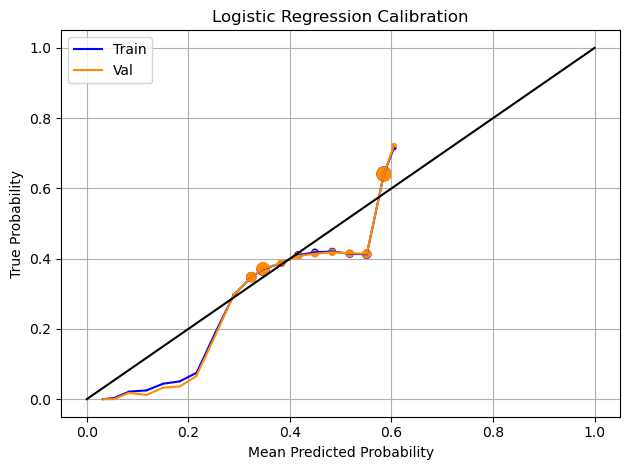

In [8]:
train_probs = best_model.predict_proba(X_train_mm)[:,1]
val_probs = best_model.predict_proba(X_val_mm)[:,1]
plot_cali_curve(y_train, train_probs, "Train", "blue")
plot_cali_curve(y_val, val_probs, "Val", "darkorange")
plt.title("Logistic Regression Calibration")
plt.ylabel("True Probability")
plt.xlabel("Mean Predicted Probability")
plt.legend(["Train", "Val"], loc="upper left")
plt.plot([0, 1], [0, 1], color='black')
plt.grid(True)
plt.tight_layout()

In [9]:
score_model(best_model, X_train_mm, y_train)
score_model(best_model, X_val_mm, y_val)

Log Loss: 0.6669, AUC: 0.6331, Accuracy: 0.5965
Log Loss: 0.6669, AUC: 0.6330, Accuracy: 0.5971


In [10]:
best_log = LogisticRegression(
    **best_params,
    max_iter=10000,
    random_state=RANDOM_SEED
)
X_full_mm = np.concatenate((X_train_mm, X_val_mm))
y_full = np.concatenate((y_train, y_val))

best_log.fit(X_full_mm, y_full)
score_model(best_log, X_query_mm, y_query)
score_model(best_log, X_test_mm, y_test)

Log Loss: 0.6668, AUC: 0.6332, Accuracy: 0.5967
Log Loss: 0.6670, AUC: 0.6326, Accuracy: 0.5963


In [11]:
# distance, angle
best_log.coef_

array([[-3.85392421,  0.04637425,  0.11626713]])